In [590]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier

import joblib

from sklearn.metrics import f1_score, classification_report, confusion_matrix

## EDA

In [591]:
ds = pd.read_csv("loan_approval_dataset.csv")
ds.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [592]:
ds.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [593]:
ds.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [594]:
# Check for missing values
ds.columns = ds.columns.str.strip()
ds.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [595]:
# I will drop loan_id
ds.drop("loan_id", axis=1, inplace=True)

There are no missing values.

In [596]:
y = ds["loan_status"]
X = ds.drop("loan_status", axis=1)

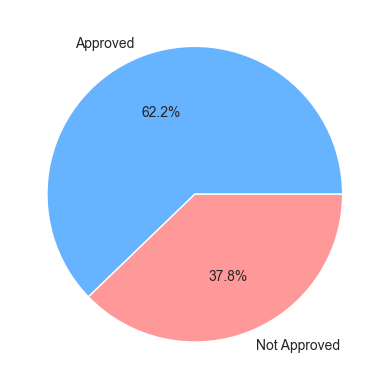

In [597]:
sns.set_style("whitegrid")
plt.pie(y.value_counts(), labels=["Approved", "Not Approved"], autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.show()

Most of loans are approved.

In [598]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
print("Numeric features:", numeric_features)
category_features = X.select_dtypes(include=["object"]).columns
print("Categorical features:", category_features)

Numeric features: Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')
Categorical features: Index(['education', 'self_employed'], dtype='object')


First, I will analyse skewness of the numeric features.

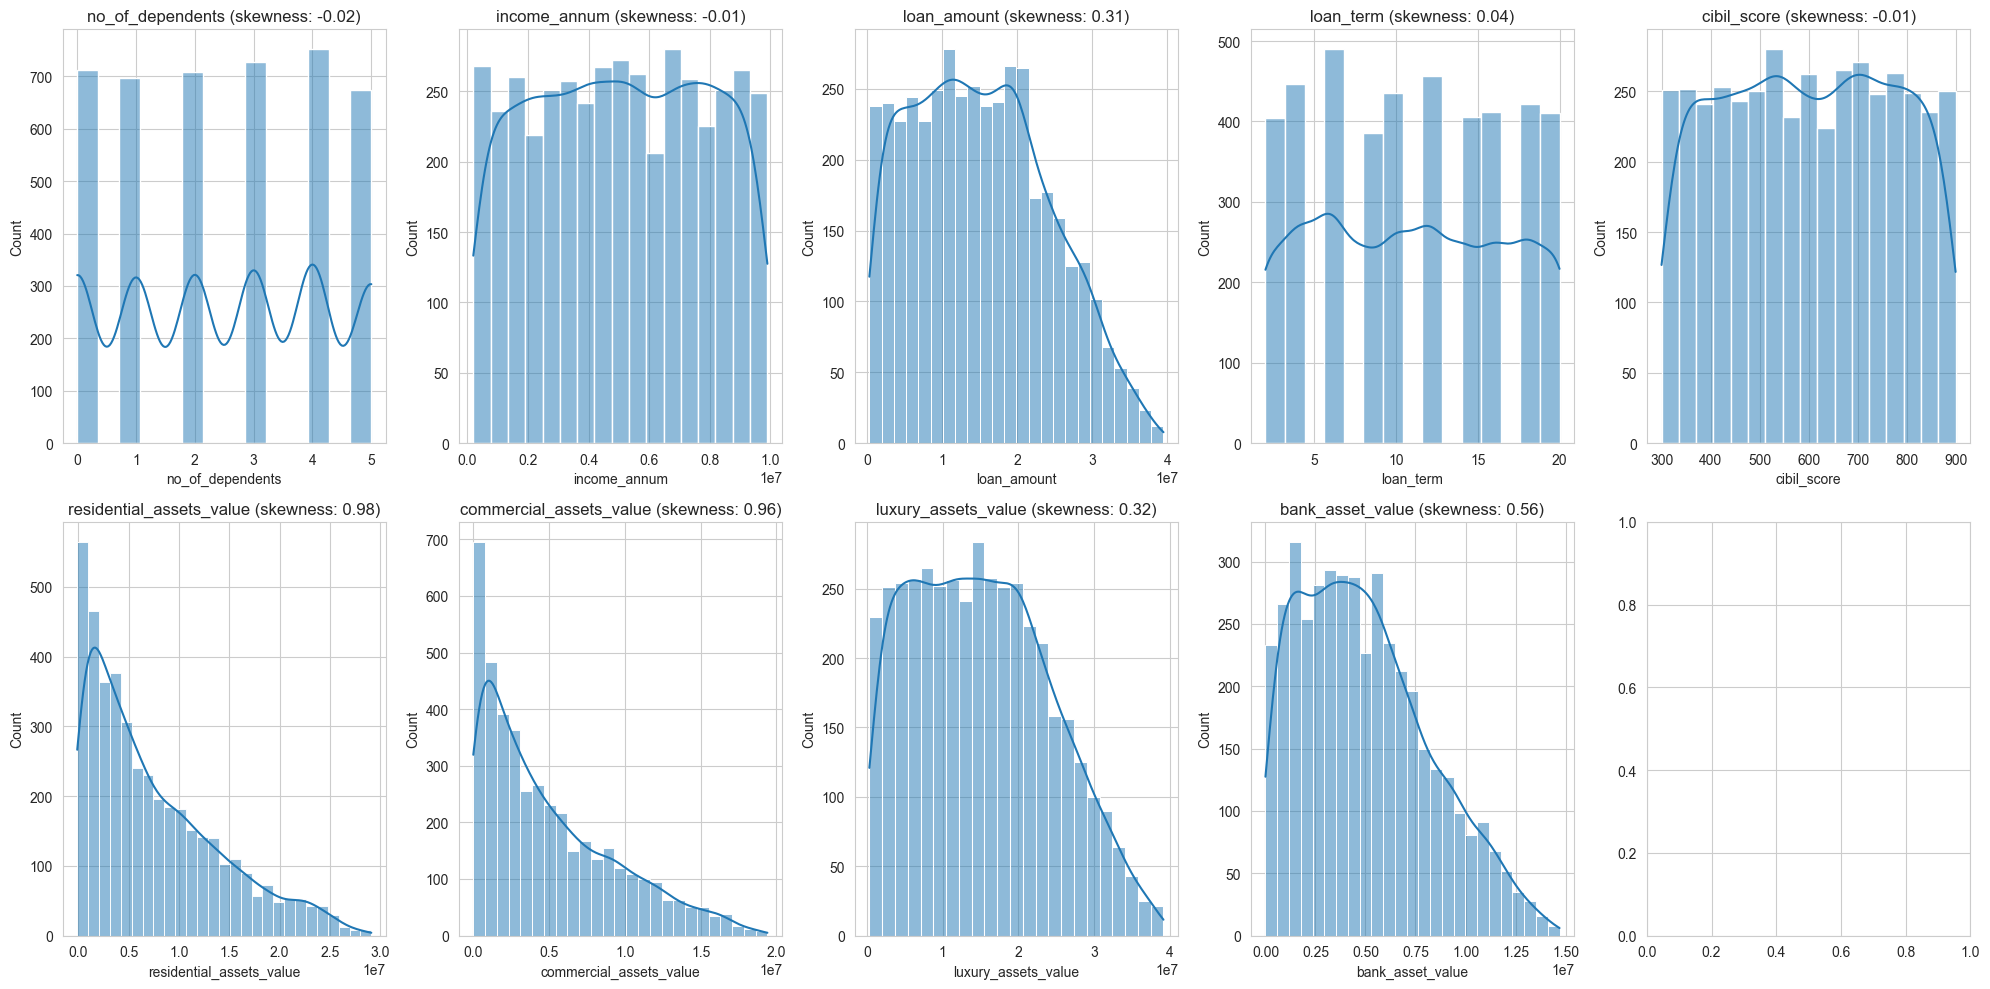

In [599]:
num_numeric = len(numeric_features)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(X[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (skewness: {X[col].skew():.2f})")

plt.tight_layout()
plt.show()


In [600]:
X.select_dtypes(include='number').skew().sort_values(ascending=False)

residential_assets_value    0.978451
commercial_assets_value     0.957791
bank_asset_value            0.560725
luxury_assets_value         0.322208
loan_amount                 0.308724
loan_term                   0.036359
cibil_score                -0.009039
income_annum               -0.012814
no_of_dependents           -0.017971
dtype: float64

We see that residential_assets_value, commercial_assets_value, and bank_assets_value are highly skewed. I will apply log transformation to these features.

In [601]:
# Let's analyse the quantiles of the highly skewed features to find outliers
skewed_features = ["residential_assets_value", "commercial_assets_value", "bank_asset_value"]
def detect_outliers_iqr(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    print(Q1, Q3)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper)

outliers_indices = set()
for feature in skewed_features:
    outliers = detect_outliers_iqr(X[feature], k=1.5)
    print(f"{feature}: {outliers.sum()} outliers")
    idx = X[feature][outliers].index
    outliers_indices.update(idx.tolist())
print(outliers_indices)
print(f"Total unique outliers: {len(outliers_indices)}")

2200000.0 11300000.0
residential_assets_value: 52 outliers
1300000.0 7600000.0
commercial_assets_value: 37 outliers
2300000.0 7100000.0
bank_asset_value: 5 outliers
{0, 1029, 4120, 2586, 554, 3119, 3631, 1591, 1609, 82, 3157, 1625, 1633, 98, 1131, 4205, 123, 2185, 1674, 4237, 2715, 157, 3234, 1194, 3763, 693, 3782, 200, 714, 3790, 1761, 228, 1254, 231, 1768, 3310, 3827, 1272, 2302, 2818, 258, 262, 2828, 781, 2318, 1805, 3860, 1812, 791, 1304, 3868, 3872, 3880, 3882, 2349, 323, 2384, 2914, 2922, 2412, 3949, 2927, 367, 3439, 2930, 1397, 2933, 2940, 892, 895, 905, 1419, 919, 924, 2976, 3498, 4010, 1965, 3000, 953, 4027, 956, 1468, 4042, 1997, 2004, 3541, 987, 997, 1002, 4074}
Total unique outliers: 91


In [602]:
outliers_items = y.loc[list(outliers_indices)]
print(outliers_items.value_counts() / len(outliers_items) * 100)

loan_status
Approved    58.241758
Rejected    41.758242
Name: count, dtype: float64


The results of loan_status on the outliers is interesting. The outliers are right-skewed, which means individuals with high values of residential_assets_value, commercial_assets_value, and bank_assets_value. But the percentage of approved loans is similar to the overall percentage and even a little lower. 

In [603]:
outlier_items = X.loc[list(outliers_indices), "income_annum"]
print(outlier_items.describe())
print(X["income_annum"].describe())

count    9.100000e+01
mean     9.409890e+06
std      3.969481e+05
min      8.500000e+06
25%      9.100000e+06
50%      9.500000e+06
75%      9.800000e+06
max      9.900000e+06
Name: income_annum, dtype: float64
count    4.269000e+03
mean     5.059124e+06
std      2.806840e+06
min      2.000000e+05
25%      2.700000e+06
50%      5.100000e+06
75%      7.500000e+06
max      9.900000e+06
Name: income_annum, dtype: float64


The annual income of outliers is also higher.

In [604]:
outlier_items = X.loc[list(outliers_indices), "loan_amount"]
print(outlier_items.describe())
print(X["loan_amount"].describe())

count    9.100000e+01
mean     2.694396e+07
std      5.476053e+06
min      1.750000e+07
25%      2.290000e+07
50%      2.560000e+07
75%      3.125000e+07
max      3.880000e+07
Name: loan_amount, dtype: float64
count    4.269000e+03
mean     1.513345e+07
std      9.043363e+06
min      3.000000e+05
25%      7.700000e+06
50%      1.450000e+07
75%      2.150000e+07
max      3.950000e+07
Name: loan_amount, dtype: float64


Even having more assets and higher annual income, outliers have loan approval rates slightly lower than the overall approval rate. What probably explains this is the fact that the loan_amount of the outliers is also higher than the overall loan_amount. So, even if these individuals have high assets, they also ask for higher loans, which can be a reason for rejection.
Based on this, a new feature can be created: the ratio of loan_amount to the sum of assets. This feature can be a good predictor of loan approval, as it captures the relationship between the amount of loan requested and the financial strength of the applicant.

Ideas of new features:
1. **Debt-to-Income ratio**: loan_amount/annual_income
2. **Debt-to-Asset ratio**: (residential_assets_value + commercial_assets_value + bank_assets_value)/loan_amount

In [605]:
# Let's check the proportion of category features
for col in category_features:
    print(f"{col} value counts:")
    print(X[col].value_counts(normalize=True) * 100)
    print("\n")

education value counts:
education
Graduate        50.222535
Not Graduate    49.777465
Name: proportion, dtype: float64


self_employed value counts:
self_employed
Yes    50.363083
No     49.636917
Name: proportion, dtype: float64




In [606]:
ds["loan_status"] = ds['loan_status'].str.strip().eq('Approved').astype(int)
ds["loan_status"]

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [607]:
numeric_features = ds.select_dtypes(include=["int64", "float64"]).columns
ds[numeric_features].corr(method="spearman")["loan_status"].sort_values(ascending=False)

loan_status                 1.000000
cibil_score                 0.771715
loan_amount                 0.012534
commercial_assets_value     0.009016
bank_asset_value           -0.009965
income_annum               -0.015059
residential_assets_value   -0.016414
luxury_assets_value        -0.017256
no_of_dependents           -0.018115
loan_term                  -0.114738
Name: loan_status, dtype: float64

In [608]:
print(ds['cibil_score'].describe())

count    4269.000000
mean      599.936051
std       172.430401
min       300.000000
25%       453.000000
50%       600.000000
75%       748.000000
max       900.000000
Name: cibil_score, dtype: float64


In [609]:
# Calculating Mutual Information
X_encoded = pd.get_dummies(X, drop_first=True)
mi_scores = mutual_info_classif(X_encoded, y)
mi_scores_series = pd.Series(mi_scores, index=X_encoded.columns)
print(mi_scores_series.sort_values(ascending=False))

cibil_score                 0.504458
loan_amount                 0.015141
loan_term                   0.007895
no_of_dependents            0.005641
luxury_assets_value         0.003850
commercial_assets_value     0.001566
income_annum                0.000000
residential_assets_value    0.000000
bank_asset_value            0.000000
education_ Not Graduate     0.000000
self_employed_ Yes          0.000000
dtype: float64


It looks like cibil_score has a strong correlation with loan_status. I will check the box plot between cibil_score and loan_status.

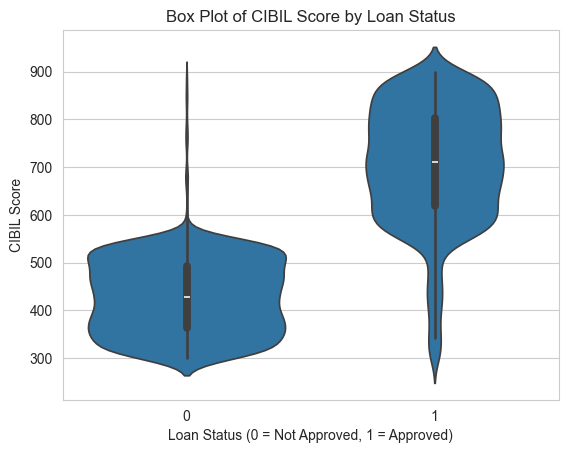

In [610]:
sns.violinplot(x="loan_status", y="cibil_score", data=ds)
plt.title("Box Plot of CIBIL Score by Loan Status")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("CIBIL Score")
plt.show()

Text(0, 0.5, 'Annual Income')

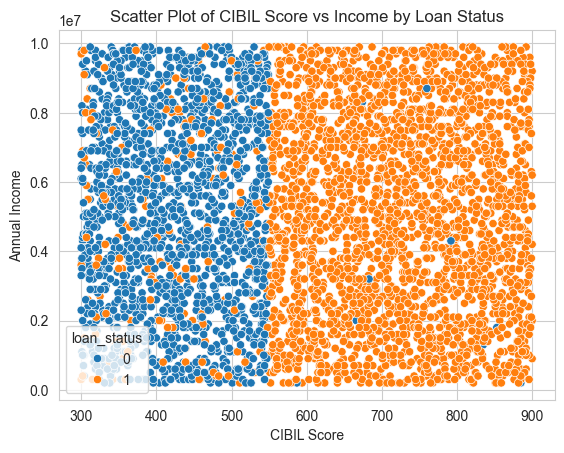

In [611]:
sns.scatterplot(x="cibil_score", y="income_annum", hue="loan_status", data=ds)
plt.title("Scatter Plot of CIBIL Score vs Income by Loan Status")
plt.xlabel("CIBIL Score")
plt.ylabel("Annual Income")

We see here that CIBIL_Score is defnitely the most important feature, specially to classify a loan as approved.
A binary logistic regression model on CIBIL_score alone on CIBIL_score is already a good baseline

## Model training

Metric evaluation:
- F1-score: 2 * precision * recall/ (precision + recall)
- Precision here lowers the money lost by the bank.
- Recall here increases the number of approved loans, which can increase the profit of the bank.

In [612]:
ds.rename({" loan_status": "loan_status"}, axis=1, inplace=True)

In [613]:
# Splitting 30% test, 70% train
train, test = train_test_split(ds, test_size=0.3, random_state=42, stratify=ds["loan_status"])

X_train = train.drop("loan_status", axis=1)
y_train = train["loan_status"]
X_test = test.drop("loan_status", axis=1)
y_test = test["loan_status"]

In [614]:
log_transform_cols = ["residential_assets_value", "commercial_assets_value", "bank_asset_value"]
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
category_features = X_train.columns.difference(numeric_cols).tolist()

In [615]:
# remaining_numeric = [c for c in numeric_features if c not in log_transform_cols and c != "loan_status"]

preprocessor = ColumnTransformer([
    ("log", PowerTransformer(method="yeo-johnson"), log_transform_cols),
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(), category_features)
])

In [616]:
# Defining the pipelines
pipeline_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

pipeline_boost = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier())
])

pipeline_random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

In [617]:
sklearn_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}
xgb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [3, 5, 7]
}
random_forest_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5]
}


grid_linear = GridSearchCV(pipeline_linear, sklearn_param_grid, cv=5, scoring="f1")
grid_xgb = GridSearchCV(pipeline_boost, xgb_param_grid, cv=5, scoring="f1")
grid_random_forest = GridSearchCV(pipeline_random_forest, random_forest_param_grid, cv=5, scoring="f1")

In [618]:
X_train.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

In [619]:
# Training
grid_linear.fit(X_train, y_train)
grid_xgb.fit(X_train, y_train)
grid_random_forest.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('log', ...), ('num', ...), ...]"


In [620]:
ensemble = VotingClassifier(estimators=[
    ("logistic", grid_linear.best_estimator_),
    ("xgb", grid_xgb.best_estimator_),
    ("random_forest", grid_random_forest.best_estimator_)
], voting="soft")

ensemble.fit(X_train, y_train)

,estimators,"[('logistic', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,transformers,"[('log', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [621]:
# Evaluating the models
y_pred_linear = grid_linear.predict(X_test)
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_random_forest = grid_random_forest.predict(X_test)

# Blending the predictions (majority vote)
y_pred_blend = ensemble.predict(X_test)

In [622]:
# Getting how many times xgboost predicted 1
print("XGBoost predicted 1:", y_pred_xgb.sum(), "out of", len(y_pred_xgb))

XGBoost predicted 1: 795 out of 1281


In [623]:
# Calculating F1-score for each model
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_linear))
f1_linear = f1_score(y_test, y_pred_linear)
print(f"F1-score for Logistic Regression: {f1_linear:.4f}")

print()

print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))
f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"F1-score for XGBoost: {f1_xgb:.4f}")

print()

print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_random_forest))
f1_random_forest = f1_score(y_test, y_pred_random_forest)
print(f"F1-score for Random Forest: {f1_random_forest:.4f}")

print()

print("Classification Report for Blended Model:")
print(classification_report(y_test, y_pred_blend))

f1_blend = f1_score(y_test, y_pred_blend)
print(f"F1-score for Blended Model: {f1_blend:.4f}")

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       484
           1       0.92      0.94      0.93       797

    accuracy                           0.91      1281
   macro avg       0.91      0.90      0.90      1281
weighted avg       0.91      0.91      0.91      1281

F1-score for Logistic Regression: 0.9284

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       484
           1       0.99      0.99      0.99       797

    accuracy                           0.99      1281
   macro avg       0.99      0.99      0.99      1281
weighted avg       0.99      0.99      0.99      1281

F1-score for XGBoost: 0.9899

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       484
           1       0.99      0.99      0.9

In [624]:
# Printing the confusion matrix and classification report
print("Confusion Matrix for Blended Model:")
print(confusion_matrix(y_test, y_pred_blend))
print("\nClassification Report for Blended Model:")
print(classification_report(y_test, y_pred_blend))

Confusion Matrix for Blended Model:
[[475   9]
 [ 18 779]]

Classification Report for Blended Model:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       484
           1       0.99      0.98      0.98       797

    accuracy                           0.98      1281
   macro avg       0.98      0.98      0.98      1281
weighted avg       0.98      0.98      0.98      1281



In [625]:
# Saving models and the pre-processors
joblib.dump(preprocessor, "preprocessor.pkl")

joblib.dump(grid_linear.best_estimator_, "logistic_regression_model.pkl")
joblib.dump(grid_xgb.best_estimator_, "xgboost_model.pkl")
joblib.dump(grid_random_forest.best_estimator_, "random_forest_model.pkl")

['random_forest_model.pkl']